Shape: (45211, 17)
Target distribution:
y
no     39922
yes     5289
Name: count, dtype: int64

Training samples : 36,168
Testing samples  : 9,043

Accuracy: 88.76%
              precision    recall  f1-score   support

          No       0.90      0.98      0.94      7952
         Yes       0.59      0.24      0.34      1091

    accuracy                           0.89      9043
   macro avg       0.74      0.61      0.64      9043
weighted avg       0.86      0.89      0.87      9043


Top features:
duration    0.680324
month       0.138077
age         0.080303
pdays       0.070203
contact     0.029024
day         0.002070
job         0.000000
marital     0.000000
dtype: float64


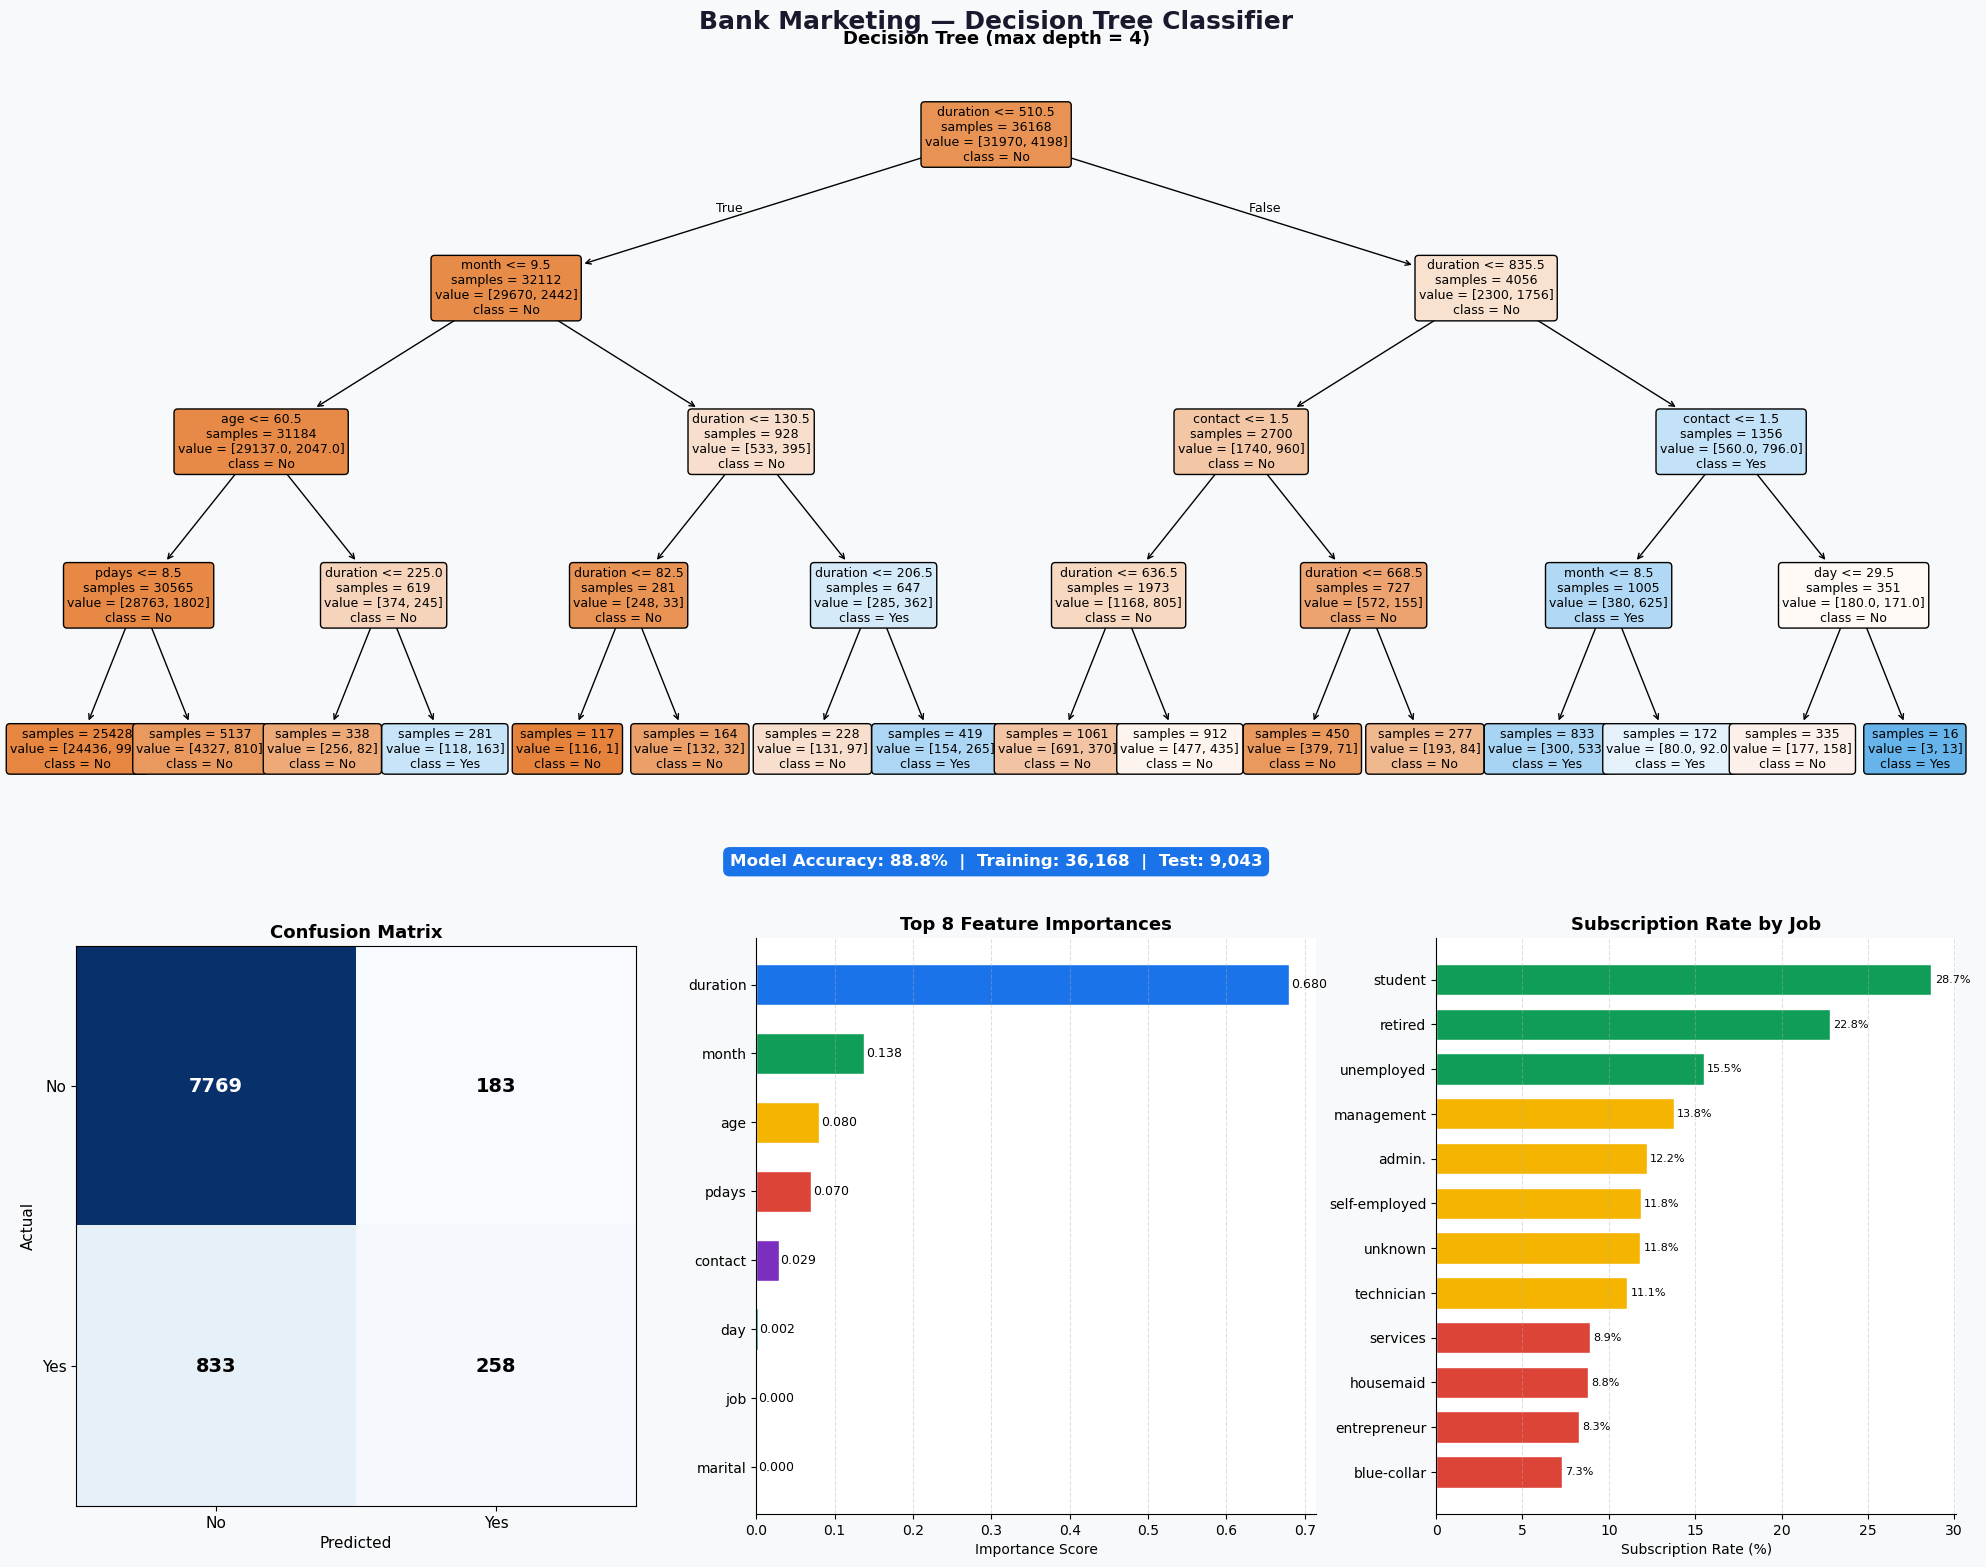

Done!


In [1]:
# ============================================================
# PRODIGY INFOTECH — Data Science Internship
# Task 03: Decision Tree Classifier
# Dataset: Bank Marketing — UCI / bank-full.csv
# Author: Edmond Wehbe
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score)
import warnings
warnings.filterwarnings('ignore')

# ── 1. LOAD DATA ─────────────────────────────────────────────
file_path = r"C:\Users\Lenovo\OneDrive\Desktop\task3-prodigy\bank-full.csv"
df = pd.read_csv(file_path, sep=';')
print(f"Shape: {df.shape}")
print(f"Target distribution:\n{df['y'].value_counts()}")

# ── 2. ENCODE CATEGORICAL COLUMNS ────────────────────────────
df_enc = df.copy()
le = LabelEncoder()
cat_cols = df_enc.select_dtypes(include='object').columns
for col in cat_cols:
    df_enc[col] = le.fit_transform(df_enc[col])

# ── 3. SPLIT DATA ─────────────────────────────────────────────
X = df_enc.drop('y', axis=1)
y = df_enc['y']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"\nTraining samples : {len(X_train):,}")
print(f"Testing samples  : {len(X_test):,}")

# ── 4. TRAIN DECISION TREE ────────────────────────────────────
dt = DecisionTreeClassifier(max_depth=4, random_state=42,
                             min_samples_split=50)
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)

# ── 5. EVALUATE ───────────────────────────────────────────────
acc = accuracy_score(y_test, y_pred) * 100
print(f"\nAccuracy: {acc:.2f}%")
print(classification_report(y_test, y_pred, target_names=['No','Yes']))

# ── 6. FEATURE IMPORTANCE ─────────────────────────────────────
feat_imp = pd.Series(dt.feature_importances_,
                     index=X.columns).sort_values(ascending=False)
print(f"\nTop features:\n{feat_imp.head(8)}")

# ── 7. COLORS ─────────────────────────────────────────────────
BLUE   = '#1A73E8'; RED    = '#DB4437'
GREEN  = '#0F9D58'; ORANGE = '#F4B400'
PURPLE = '#7B2FBE'; TEAL   = '#00897B'

# ── 8. PLOT ───────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 16))
fig.patch.set_facecolor('#F8F9FA')
fig.suptitle('Bank Marketing — Decision Tree Classifier',
             fontsize=18, fontweight='bold', y=0.99, color='#1A1A2E')

# Decision Tree visual
ax_tree = fig.add_axes([0.01, 0.48, 0.98, 0.48])
plot_tree(dt, feature_names=X.columns.tolist(),
          class_names=['No','Yes'],
          filled=True, rounded=True, fontsize=9,
          ax=ax_tree, impurity=False)
ax_tree.set_title('Decision Tree (max depth = 4)',
                  fontsize=13, fontweight='bold', pad=10)

# Confusion Matrix
ax2 = fig.add_axes([0.04, 0.05, 0.28, 0.36])
cm = confusion_matrix(y_test, y_pred)
ax2.imshow(cm, cmap='Blues')
ax2.set_xticks([0,1]); ax2.set_yticks([0,1])
ax2.set_xticklabels(['No','Yes'], fontsize=11)
ax2.set_yticklabels(['No','Yes'], fontsize=11)
ax2.set_xlabel('Predicted', fontsize=11)
ax2.set_ylabel('Actual', fontsize=11)
ax2.set_title('Confusion Matrix', fontsize=13, fontweight='bold')
for i in range(2):
    for j in range(2):
        ax2.text(j, i, str(cm[i,j]), ha='center', va='center',
                 fontsize=14, fontweight='bold',
                 color='white' if cm[i,j] > cm.max()/2 else 'black')

# Feature Importance
ax3 = fig.add_axes([0.38, 0.05, 0.28, 0.36])
top8 = feat_imp.head(8)
colors_f = [BLUE,GREEN,ORANGE,RED,PURPLE,TEAL,'#E91E63','#FF7043']
bars = ax3.barh(top8.index[::-1], top8.values[::-1],
                color=colors_f[::-1], edgecolor='white', height=0.6)
ax3.set_xlabel('Importance Score', fontsize=10)
ax3.set_title('Top 8 Feature Importances', fontsize=13, fontweight='bold')
ax3.spines[['top','right']].set_visible(False)
ax3.grid(axis='x', linestyle='--', alpha=0.4)
for bar, val in zip(bars, top8.values[::-1]):
    ax3.text(bar.get_width()+0.002, bar.get_y()+bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)

# Subscription rate by job
ax4 = fig.add_axes([0.72, 0.05, 0.26, 0.36])
job_rate = df.groupby('job')['y'].apply(
    lambda x: (x=='yes').mean()*100).sort_values()
colors_j = [GREEN if v >= 15 else ORANGE if v >= 10 else RED
            for v in job_rate.values]
ax4.barh(job_rate.index, job_rate.values,
         color=colors_j, edgecolor='white', height=0.7)
ax4.set_xlabel('Subscription Rate (%)', fontsize=10)
ax4.set_title('Subscription Rate by Job', fontsize=13, fontweight='bold')
ax4.spines[['top','right']].set_visible(False)
ax4.grid(axis='x', linestyle='--', alpha=0.4)
for i, val in enumerate(job_rate.values):
    ax4.text(val+0.2, i, f'{val:.1f}%', va='center', fontsize=8)

# Accuracy badge
fig.text(0.5, 0.455,
         f'Model Accuracy: {acc:.1f}%  |  '
         f'Training: {len(X_train):,}  |  Test: {len(X_test):,}',
         ha='center', fontsize=12, fontweight='bold', color='white',
         bbox=dict(boxstyle='round,pad=0.4',
                   facecolor=BLUE, edgecolor='none'))

plt.tight_layout()
plt.savefig('task03_decision_tree.png', dpi=150,
            bbox_inches='tight', facecolor='#F8F9FA')
plt.show()
print("Done!")